In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import train_test_split, KFold, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, make_scorer
from sklearn.inspection import PartialDependenceDisplay
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
from utils.utils import PolicyEDA
eda = PolicyEDA()

/home/tony-ubuntu/anaconda3/envs/cpa_env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")

In [5]:
# import IEA scored data
policy_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_scored_cpsi.csv"))
policy_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7
0,AFG,1971,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
1,AFG,1972,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
2,AFG,1973,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
3,AFG,1974,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752
4,AFG,1975,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752


In [6]:
policy_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9255 entries, 0 to 9254
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        9255 non-null   object 
 1   year               9255 non-null   int64  
 2   avg_policy_score   9255 non-null   float64
 3   policy_count       9255 non-null   int64  
 4   dominant_topic     9255 non-null   object 
 5   dominant_category  9255 non-null   object 
 6   log_policy_count   9255 non-null   float64
 7   CPSI               9255 non-null   float64
 8   CPSI_power_3       9255 non-null   float64
 9   CPSI_geom_4        9255 non-null   float64
 10  CPSI_geom_7        9255 non-null   float64
dtypes: float64(6), int64(2), object(3)
memory usage: 795.5+ KB


In [7]:
# import emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions.csv"))
emissions_df.head()

,iso_alpha_3,income_group,region,year,total_emissions
0,ABW,High income,Latin America & Caribbean,2000,0.335765
1,ABW,High income,Latin America & Caribbean,2001,0.344135
2,ABW,High income,Latin America & Caribbean,2002,0.363222
3,ABW,High income,Latin America & Caribbean,2003,0.412246
4,ABW,High income,Latin America & Caribbean,2004,0.430187


In [8]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      4485 non-null   object 
 1   income_group     4485 non-null   object 
 2   region           4485 non-null   object 
 3   year             4485 non-null   int64  
 4   total_emissions  4485 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 175.3+ KB


In [9]:
# import wb controls
wb_controls_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_control_vars.csv"))
wb_controls_df.head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
0,2022,1.040350e+12,731821393.0,565.488909,NaN,7.303970,37.909012,26.921919,29.737205,NaN
1,2021,1.004646e+12,713090928.0,570.998888,NaN,7.156658,37.393633,26.075267,29.955194,NaN
2,2020,9.606813e+11,694446100.0,563.976201,66.123449,7.107927,36.884034,25.434235,30.174252,NaN
3,2019,9.890095e+11,675950189.0,586.441491,63.387090,7.212707,36.384272,26.421751,30.391626,NaN
4,2018,9.677734e+11,657801085.0,583.763039,62.242631,7.273489,35.893398,27.859732,30.611512,NaN


In [10]:
wb_controls_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6118 entries, 0 to 6117
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               6118 non-null   int64  
 1   gdp_2015_usd       5832 non-null   float64
 2   population         6095 non-null   float64
 3   energy_per_capita  4565 non-null   float64
 4   renewable_share    5710 non-null   float64
 5   energy_intensity   4404 non-null   float64
 6   urbanization_rate  6049 non-null   float64
 7   industry_size      5551 non-null   float64
 8   forest_area        5953 non-null   float64
 9   iso_alpha_3        4945 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 478.1+ KB


In [11]:
policy_emissions_df = pd.merge(policy_df, emissions_df, on=["iso_alpha_3", "year"], how="inner")
policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,total_emissions
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,25.390391
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,23.723115
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,26.383509
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.071538
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,1.643752,Low income,South Asia,27.128799


In [12]:
# check if USA is in the data
policy_emissions_df[policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,CPSI_geom_7,income_group,region,total_emissions
3965,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,27.070635,High income,North America,6318.595153
3966,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,29.368590,High income,North America,6237.645614
3967,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,32.523942,High income,North America,6102.809992
3968,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,34.925083,High income,North America,6142.901629
3969,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,39.204911,High income,North America,6313.734481


In [13]:
wb_controls_df[wb_controls_df["iso_alpha_3"] == "USA"].head()

,year,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,iso_alpha_3
5865,2022,2.144339e+13,333271411.0,6520.176697,NaN,11.171772,83.084,NaN,33.866926,USA
5866,2021,2.091785e+13,332048977.0,6441.742879,10.9,11.071275,82.873,17.608172,33.866926,USA
5867,2020,1.972358e+13,331526933.0,6138.375293,11.0,10.972348,82.664,17.267677,33.866926,USA
5868,2019,2.015964e+13,328329953.0,6736.457903,10.2,10.318741,82.459,18.145484,33.866926,USA
5869,2018,1.965187e+13,326838199.0,6770.788961,9.9,10.053513,82.256,18.519546,33.866926,USA


In [14]:
# Now let's merge the wb controls data
policy_emissions_df = pd.merge(policy_emissions_df, wb_controls_df, on=["iso_alpha_3", "year"], how="inner")
policy_emissions_df.head()

,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,region,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
0,AFG,2000,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,25.390391,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782
1,AFG,2001,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,23.723115,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782
2,AFG,2002,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,26.383509,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782
3,AFG,2003,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.071538,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782
4,AFG,2004,0.75,1,Energy,Solar Power,0.693147,0.51986,0.644646,1.490182,...,South Asia,27.128799,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782


In [15]:
# check if USA is in the data
policy_emissions_df[policy_emissions_df["iso_alpha_3"] == "USA"].head()


,iso_alpha_3,year,avg_policy_score,policy_count,dominant_topic,dominant_category,log_policy_count,CPSI,CPSI_power_3,CPSI_geom_4,...,region,total_emissions,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area
3943,USA,2000,0.459459,74,Cross-cutting / Economy-wide,Other,4.317488,1.983711,9.446749,16.263613,...,North America,6318.595153,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174
3944,USA,2001,0.460366,82,Cross-cutting / Economy-wide,Other,4.418841,2.034283,10.106958,17.469706,...,North America,6237.645614,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756
3945,USA,2002,0.446809,94,Cross-cutting / Economy-wide,Other,4.553877,2.034711,10.700017,19.030183,...,North America,6102.809992,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338
3946,USA,2003,0.444175,103,Cross-cutting / Economy-wide,Other,4.644391,2.062921,11.271911,20.239021,...,North America,6142.901629,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920
3947,USA,2004,0.461864,118,Cross-cutting / Economy-wide,Other,4.779123,2.207307,12.772495,22.502834,...,North America,6313.734481,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502


In [16]:
## remove unnecessary columns
policy_emissions_df = policy_emissions_df.drop(columns=["avg_policy_score", 
                                                        "policy_count", 
                                                        "dominant_topic",
                                                        "dominant_category",
                                                        "CPSI",
                                                        "CPSI_power_3",
                                                        "CPSI_geom_4",])

# move total_emissions to the end
policy_emissions_df = policy_emissions_df[[col for col in policy_emissions_df.columns if col != "total_emissions"] + ["total_emissions"]]
policy_emissions_df.head()

,iso_alpha_3,year,log_policy_count,CPSI_geom_7,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.693147,1.643752,Low income,South Asia,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.693147,1.643752,Low income,South Asia,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.693147,1.643752,Low income,South Asia,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.693147,1.643752,Low income,South Asia,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.693147,1.643752,Low income,South Asia,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [17]:
# Rename CPSI_geom_7 to CPSI
policy_emissions_df = policy_emissions_df.rename(columns={"CPSI_geom_7": "CPSI"})
policy_emissions_df.head()

,iso_alpha_3,year,log_policy_count,CPSI,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AFG,2000,0.693147,1.643752,Low income,South Asia,6.206548e+09,20130327.0,NaN,45.0,NaN,22.078,NaN,1.852782,25.390391
1,AFG,2001,0.693147,1.643752,Low income,South Asia,5.621148e+09,20284307.0,NaN,45.6,NaN,22.169,NaN,1.852782,23.723115
2,AFG,2002,0.693147,1.643752,Low income,South Asia,7.228796e+09,21378117.0,NaN,37.8,NaN,22.261,23.810127,1.852782,26.383509
3,AFG,2003,0.693147,1.643752,Low income,South Asia,7.867263e+09,22733049.0,NaN,36.7,NaN,22.353,22.710864,1.852782,27.071538
4,AFG,2004,0.693147,1.643752,Low income,South Asia,7.978516e+09,23560654.0,NaN,44.2,NaN,22.500,26.226790,1.852782,27.128799


In [18]:
policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4165 entries, 0 to 4164
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        4165 non-null   object 
 1   year               4165 non-null   int64  
 2   log_policy_count   4165 non-null   float64
 3   CPSI               4165 non-null   float64
 4   income_group       4165 non-null   object 
 5   region             4165 non-null   object 
 6   gdp_2015_usd       4092 non-null   float64
 7   population         4165 non-null   float64
 8   energy_per_capita  3353 non-null   float64
 9   renewable_share    4028 non-null   float64
 10  energy_intensity   3257 non-null   float64
 11  urbanization_rate  4165 non-null   float64
 12  industry_size      3994 non-null   float64
 13  forest_area        4126 non-null   float64
 14  total_emissions    4165 non-null   float64
dtypes: float64(11), int64(1), object(3)
memory usage: 488.2+ KB


In [19]:
oecd_countries_iso3 = eda.get_oecd_iso_codes()
oecd_policy_emissions_df = policy_emissions_df[policy_emissions_df["iso_alpha_3"].isin(oecd_countries_iso3)].reset_index(drop=True)
oecd_policy_emissions_df.head()

,iso_alpha_3,year,log_policy_count,CPSI,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
0,AUS,2000,3.555348,14.737193,High income,East Asia & Pacific,8.726517e+11,19028802.0,5681.228859,8.4,7.923112,84.235,24.550533,17.158156,581.422036
1,AUS,2001,3.583519,15.434088,High income,East Asia & Pacific,8.903238e+11,19274701.0,5486.394559,8.4,8.263839,84.100,23.633521,17.128633,602.437642
2,AUS,2002,3.637586,16.109152,High income,East Asia & Pacific,9.257550e+11,19495210.0,5480.234643,8.7,8.505064,84.222,23.611732,17.099111,606.209253
3,AUS,2003,3.737670,17.755269,High income,East Asia & Pacific,9.543678e+11,19720737.0,5615.576756,7.2,8.458763,84.343,24.042096,17.069589,607.749769
4,AUS,2004,3.988984,21.591609,High income,East Asia & Pacific,9.946831e+11,19932722.0,5652.130379,6.7,8.665917,84.463,23.934919,17.040066,608.183791


In [20]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        847 non-null    object 
 1   year               847 non-null    int64  
 2   log_policy_count   847 non-null    float64
 3   CPSI               847 non-null    float64
 4   income_group       847 non-null    object 
 5   region             847 non-null    object 
 6   gdp_2015_usd       847 non-null    float64
 7   population         847 non-null    float64
 8   energy_per_capita  847 non-null    float64
 9   renewable_share    810 non-null    float64
 10  energy_intensity   847 non-null    float64
 11  urbanization_rate  847 non-null    float64
 12  industry_size      843 non-null    float64
 13  forest_area        846 non-null    float64
 14  total_emissions    847 non-null    float64
dtypes: float64(11), int64(1), object(3)
memory usage: 99.4+ KB


In [21]:
oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].head()

,iso_alpha_3,year,log_policy_count,CPSI,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
824,USA,2000,4.317488,27.070635,High income,North America,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174,6318.595153
825,USA,2001,4.418841,29.368590,High income,North America,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614
826,USA,2002,4.553877,32.523942,High income,North America,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992
827,USA,2003,4.644391,34.925083,High income,North America,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629
828,USA,2004,4.779123,39.204911,High income,North America,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481


## EDA

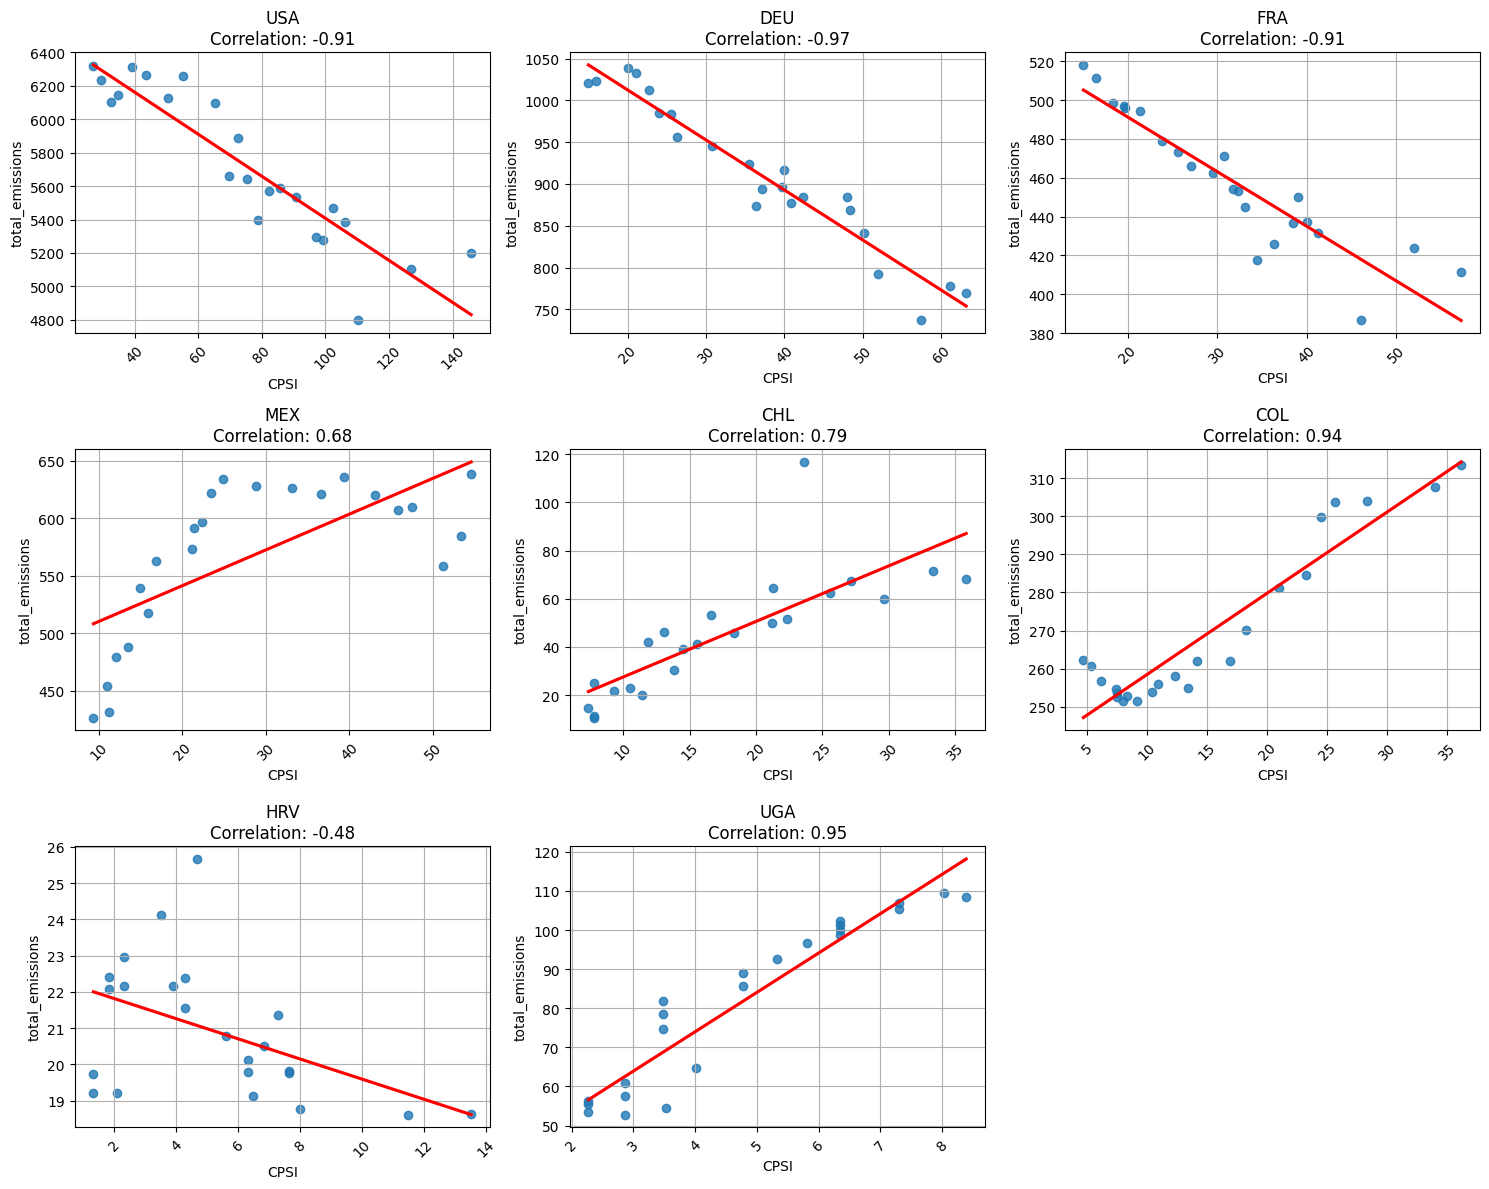

In [22]:
interesting_countries = ["USA", "DEU", "FRA", "MEX", "CHL", "COL", "HRV", "UGA"]
eda.plot_correlation_multiple(policy_emissions_df, "CPSI", "total_emissions", interesting_countries)

In [23]:
# eda.plot_correlation_multiple(policy_emissions_df, "CPSI", "rel_change", oecd_countries_iso3)

In [24]:
# for iso_code in intersting_countries:
#     eda.plot_correlation_matrix(oecd_policy_emissions_df, iso_code)

In [25]:
countries_corr_df = eda.calculate_corr_coef_for_each_country(oecd_policy_emissions_df, "CPSI", "total_emissions", oecd_countries_iso3)
countries_corr_df.sort_values(by="correlation", ascending=True).reset_index(drop=True)

,iso_alpha_3,correlation
0,NLD,-0.966206
1,DEU,-0.966032
2,BEL,-0.959197
3,ITA,-0.918302
4,GRC,-0.917536
5,FRA,-0.913326
6,USA,-0.908925
7,GBR,-0.908525
8,DNK,-0.892573
9,CHE,-0.891012


In [26]:
avg_cpsi_emissions_df = oecd_policy_emissions_df.groupby("iso_alpha_3")[["CPSI", "total_emissions"]].mean().reset_index()
avg_cpsi_emissions_df.rename(columns={"CPSI": "avg_cpsi", "total_emissions": "avg_total_emissions"}, inplace=True)

# Calculate log of avg_total_emissions
avg_cpsi_emissions_df["log_avg_total_emissions"] = np.log(avg_cpsi_emissions_df["avg_total_emissions"])
avg_cpsi_emissions_df.head()

,iso_alpha_3,avg_cpsi,avg_total_emissions,log_avg_total_emissions
0,AUS,38.159703,589.449485,6.379189
1,AUT,20.471678,81.327603,4.398485
2,BEL,20.957603,133.387959,4.893262
3,CAN,38.748708,726.135085,6.587736
4,CHE,20.586896,50.144064,3.914900


In [27]:
avg_cpsi_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37 entries, 0 to 36
Data columns (total 4 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   iso_alpha_3              37 non-null     object 
 1   avg_cpsi                 37 non-null     float64
 2   avg_total_emissions      37 non-null     float64
 3   log_avg_total_emissions  37 non-null     float64
dtypes: float64(3), object(1)
memory usage: 1.3+ KB


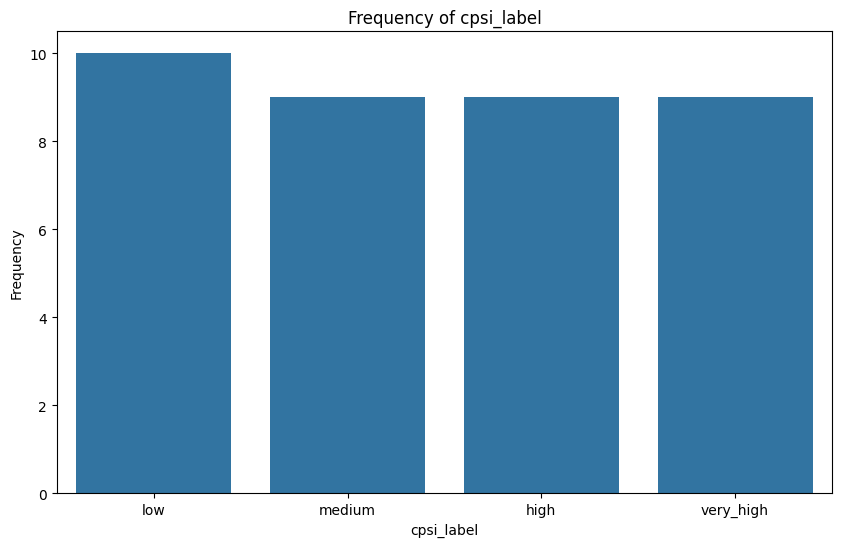

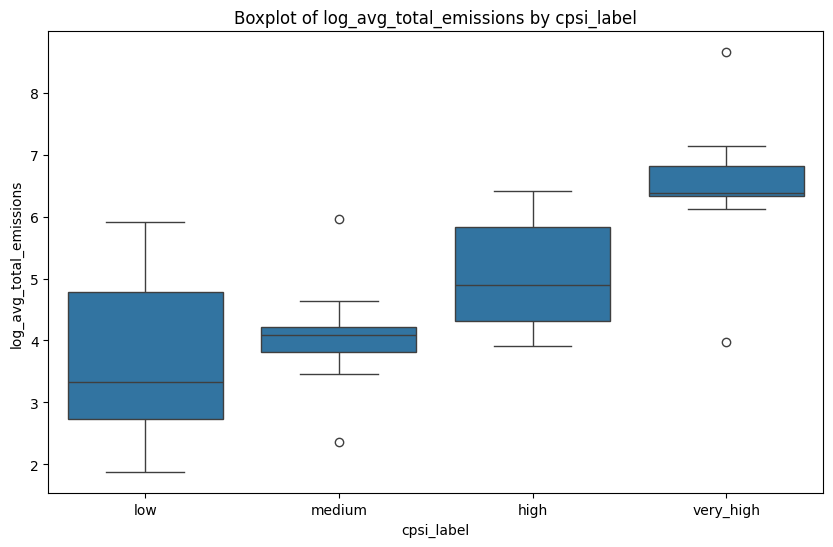

In [28]:
# label countries by their average CPSI score using quantiles
def label_countries_by_cpsi_score(df, cpsi_col, label_col):
    """
    Label countries by their average CPSI score using quantiles.
    """
    df[label_col] = pd.qcut(df[cpsi_col], q=4, labels=["low", "medium", "high", "very_high"])
    return df
avg_cpsi_emissions_df = label_countries_by_cpsi_score(avg_cpsi_emissions_df, "avg_cpsi", "cpsi_label")
# avg_cpsi_emissions_df.head()

# create frequency plot for each label
def plot_cpsi_label_frequency(df, label_col):
    """
    Plot frequency of each label.
    """
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=label_col)
    plt.title(f"Frequency of {label_col}")
    plt.xlabel(label_col)
    plt.ylabel("Frequency")
    plt.show()

plot_cpsi_label_frequency(avg_cpsi_emissions_df, "cpsi_label")

# Create a boxplot to visualize the distribution of CPSI scores for each label
def plot_cpsi_boxplot(df, emissions_col, label_col, ylim=None):
    """
    Plot boxplot of CPSI scores for each label.
    """
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=label_col, y=emissions_col)
    plt.title(f"Boxplot of {emissions_col} by {label_col}")
    plt.xlabel(label_col)
    plt.ylabel(emissions_col)

    if ylim:
        plt.ylim(ylim)

    plt.show()
plot_cpsi_boxplot(avg_cpsi_emissions_df, "log_avg_total_emissions", "cpsi_label")
# plot_cpsi_boxplot(avg_cpsi_emissions_df, "avg_rel_change", "cpsi_label", ylim=(-0.05, 0.05))

## Data preprocessing

In [29]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        847 non-null    object 
 1   year               847 non-null    int64  
 2   log_policy_count   847 non-null    float64
 3   CPSI               847 non-null    float64
 4   income_group       847 non-null    object 
 5   region             847 non-null    object 
 6   gdp_2015_usd       847 non-null    float64
 7   population         847 non-null    float64
 8   energy_per_capita  847 non-null    float64
 9   renewable_share    810 non-null    float64
 10  energy_intensity   847 non-null    float64
 11  urbanization_rate  847 non-null    float64
 12  industry_size      843 non-null    float64
 13  forest_area        846 non-null    float64
 14  total_emissions    847 non-null    float64
dtypes: float64(11), int64(1), object(3)
memory usage: 99.4+ KB


**Impute missing values**

In [30]:
# 1. Convert year to datetime
oecd_policy_emissions_df['year'] = pd.to_datetime(oecd_policy_emissions_df['year'], format='%Y')

# 2. Sort by country and year
oecd_policy_emissions_df = oecd_policy_emissions_df.sort_values(['iso_alpha_3', 'year'])

# 3. Forward-fill then backward-fill missing values per country
for col in ['renewable_share', 'industry_size', 'forest_area']:
    oecd_policy_emissions_df[col] = (
        oecd_policy_emissions_df
        .groupby('iso_alpha_3')[col]
        .transform(lambda x: x.ffill().bfill())
    )

# Convert year back to integer
oecd_policy_emissions_df['year'] = oecd_policy_emissions_df['year'].dt.year

In [31]:
oecd_policy_emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 847 entries, 0 to 846
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   iso_alpha_3        847 non-null    object 
 1   year               847 non-null    int32  
 2   log_policy_count   847 non-null    float64
 3   CPSI               847 non-null    float64
 4   income_group       847 non-null    object 
 5   region             847 non-null    object 
 6   gdp_2015_usd       847 non-null    float64
 7   population         847 non-null    float64
 8   energy_per_capita  847 non-null    float64
 9   renewable_share    847 non-null    float64
 10  energy_intensity   847 non-null    float64
 11  urbanization_rate  847 non-null    float64
 12  industry_size      847 non-null    float64
 13  forest_area        847 non-null    float64
 14  total_emissions    847 non-null    float64
dtypes: float64(11), int32(1), object(3)
memory usage: 96.1+ KB


## ML Per-Country Analysis

In [32]:
from utils.utils import RegressionUtils
rutils = RegressionUtils()

In [33]:
# 2. Define features (including year), target, and countries
FEATURES = [
    "CPSI", "gdp_2015_usd", "population",
    "energy_per_capita", "renewable_share", "energy_intensity",
    "urbanization_rate", "industry_size", "forest_area"
]
TARGET = "total_emissions"

usa_df = oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == "USA"].copy()
usa_df.head()

,iso_alpha_3,year,log_policy_count,CPSI,income_group,region,gdp_2015_usd,population,energy_per_capita,renewable_share,energy_intensity,urbanization_rate,industry_size,forest_area,total_emissions
824,USA,2000,4.317488,27.070635,High income,North America,1.371768e+13,282162411.0,8055.145489,5.4,6.832729,79.057,22.451577,33.130174,6318.595153
825,USA,2001,4.418841,29.368590,High income,North America,1.384876e+13,284968955.0,7824.243939,4.7,7.031645,79.234,21.469006,33.186756,6237.645614
826,USA,2002,4.553877,32.523942,High income,North America,1.408425e+13,287625193.0,7840.460959,4.8,7.070518,79.409,20.652475,33.243338,6102.809992
827,USA,2003,4.644391,34.925083,High income,North America,1.447799e+13,290107933.0,7791.303915,5.3,7.251444,79.583,20.739462,33.299920,6142.901629
828,USA,2004,4.779123,39.204911,High income,North America,1.503507e+13,292805298.0,7878.537171,5.5,7.378481,79.757,20.950032,33.356502,6313.734481


In [34]:
lr_results = []

for iso_code in oecd_countries_iso3:
    filtered_df = oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == iso_code].copy()
    features_filtered = rutils.filter_high_collinear_features(filtered_df, FEATURES, verbose=False)

    # Linear regression
    results_dict = rutils.train_model(filtered_df, features_filtered, TARGET, LinearRegression(), verbose=False)
    
    rmse = results_dict["rmse"]
    r2 = results_dict["r2"]
    coefs = results_dict["coefs"]
    cpsi_coef = coefs["CPSI"] if "CPSI" in coefs else None

    # Append results to list
    lr_results.append({
        "iso_alpha_3": iso_code,
        "rmse": rmse,
        "r2": r2,
        "filtered_features": features_filtered,
        "cpsi_coef": cpsi_coef,
    })

# Convert the list of results to a DataFrame
lr_results_df = pd.DataFrame(lr_results)


In [35]:
lr_results_df.sort_values(by="r2", ascending=False)

,iso_alpha_3,rmse,r2,filtered_features,cpsi_coef
12,GRC,2.057984,0.983416,"[CPSI, gdp_2015_usd, population, energy_per_ca...",-3.014326
17,ITA,7.653456,0.981282,"[CPSI, gdp_2015_usd, population, energy_per_ca...",-23.015744
19,KOR,14.460107,0.967672,"[CPSI, urbanization_rate, industry_size]",74.806875
34,TUR,15.818584,0.963011,"[CPSI, renewable_share, industry_size]",100.408756
2,BEL,1.958589,0.962997,"[CPSI, forest_area]",-10.554816
1,AUT,1.264921,0.958934,"[CPSI, energy_per_capita, renewable_share, urb...",7.512279
23,MEX,17.966487,0.938261,"[CPSI, energy_per_capita, renewable_share, ind...",89.522486
21,LTU,0.900645,0.917724,"[CPSI, energy_per_capita, industry_size]",1.066752
31,ESP,8.878139,0.907043,"[CPSI, gdp_2015_usd, population, energy_per_ca...",-4.304332
35,GBR,31.363589,0.865891,"[CPSI, gdp_2015_usd]",-54.724629


In [36]:
ridge_results = []

RIDGE_FEATURES = [
    "CPSI", "gdp_2015_usd", "renewable_share", "industry_size", "forest_area"
]

for iso_code in oecd_countries_iso3:
    filtered_df = oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == iso_code].copy()

    # Linear regression
    results_dict = rutils.train_model(filtered_df, RIDGE_FEATURES, TARGET, Ridge(alpha=1.0), verbose=False)
    
    rmse = results_dict["rmse"]
    r2 = results_dict["r2"]
    coefs = results_dict["coefs"]
    cpsi_coef = coefs["CPSI"] if "CPSI" in coefs else None

    # Append results to list
    ridge_results.append({
        "iso_alpha_3": iso_code,
        "rmse": rmse,
        "r2": r2,
        "cpsi_coef": cpsi_coef
    })

# Convert the list of results to a DataFrame
ridge_results_df = pd.DataFrame(ridge_results)

In [37]:
ridge_results_df.sort_values(by="r2", ascending=False)

,iso_alpha_3,rmse,r2,cpsi_coef
12,GRC,1.737805,0.988175,-7.824249
19,KOR,12.635544,0.975315,8.092564
17,ITA,10.473619,0.964947,-25.244923
36,USA,79.229663,0.956405,-21.675037
23,MEX,16.183551,0.949907,5.553993
34,TUR,18.753701,0.948011,36.341341
2,BEL,2.376620,0.945516,-3.391664
35,GBR,20.622847,0.942017,-2.356357
0,AUS,12.464625,0.921029,-13.301403
20,LVA,1.347510,0.910874,0.414008


In [38]:
from utils.utils import ShapUtils

sutils = ShapUtils()

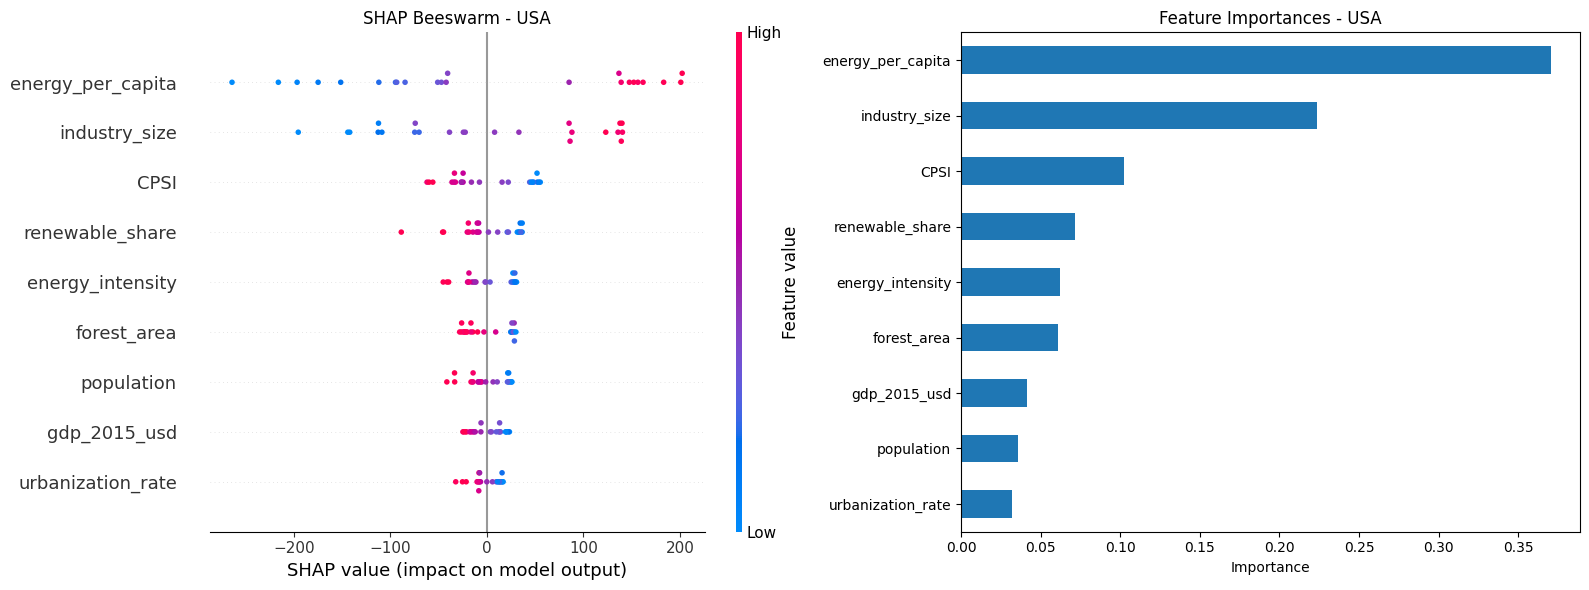

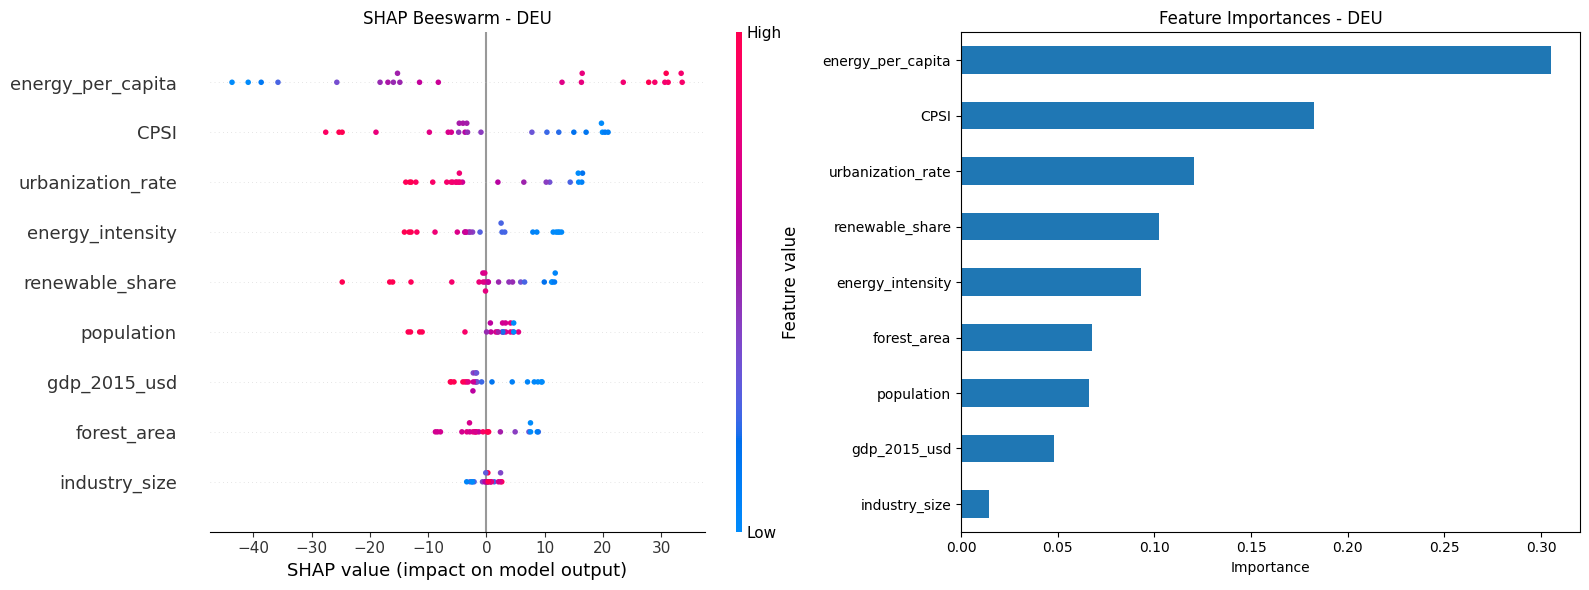

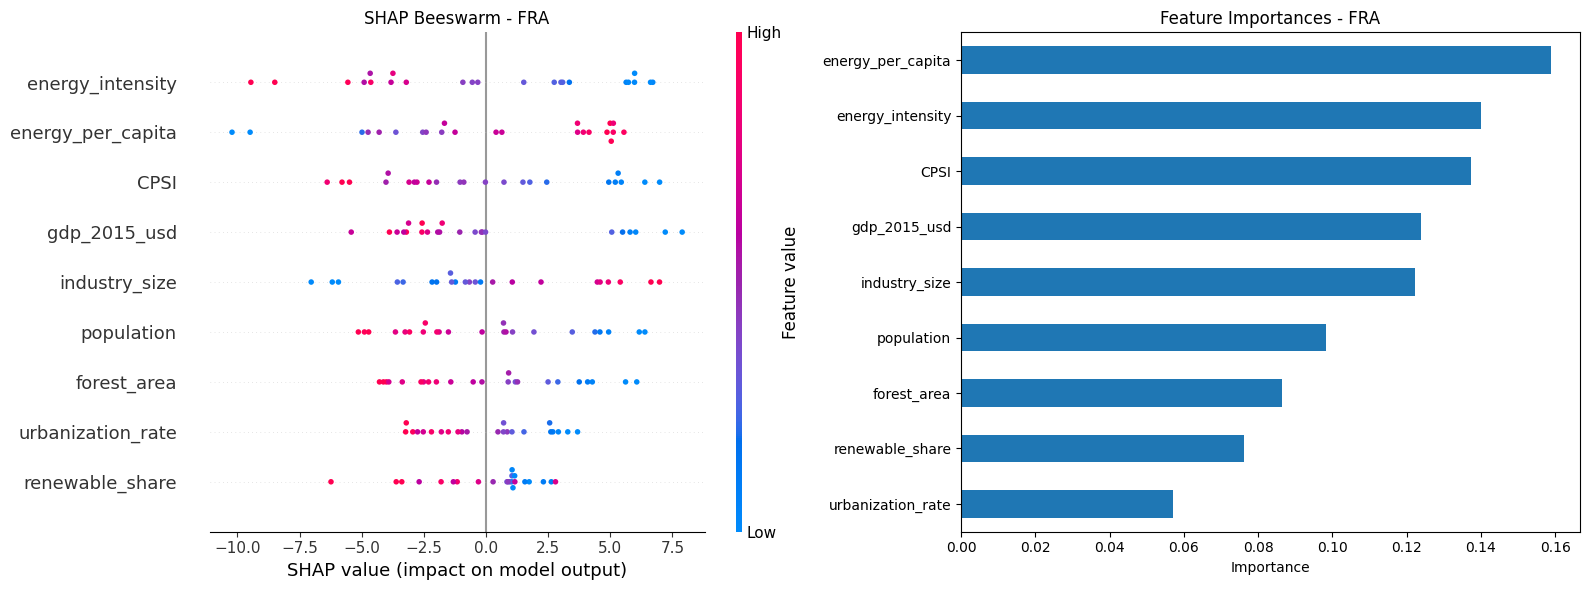

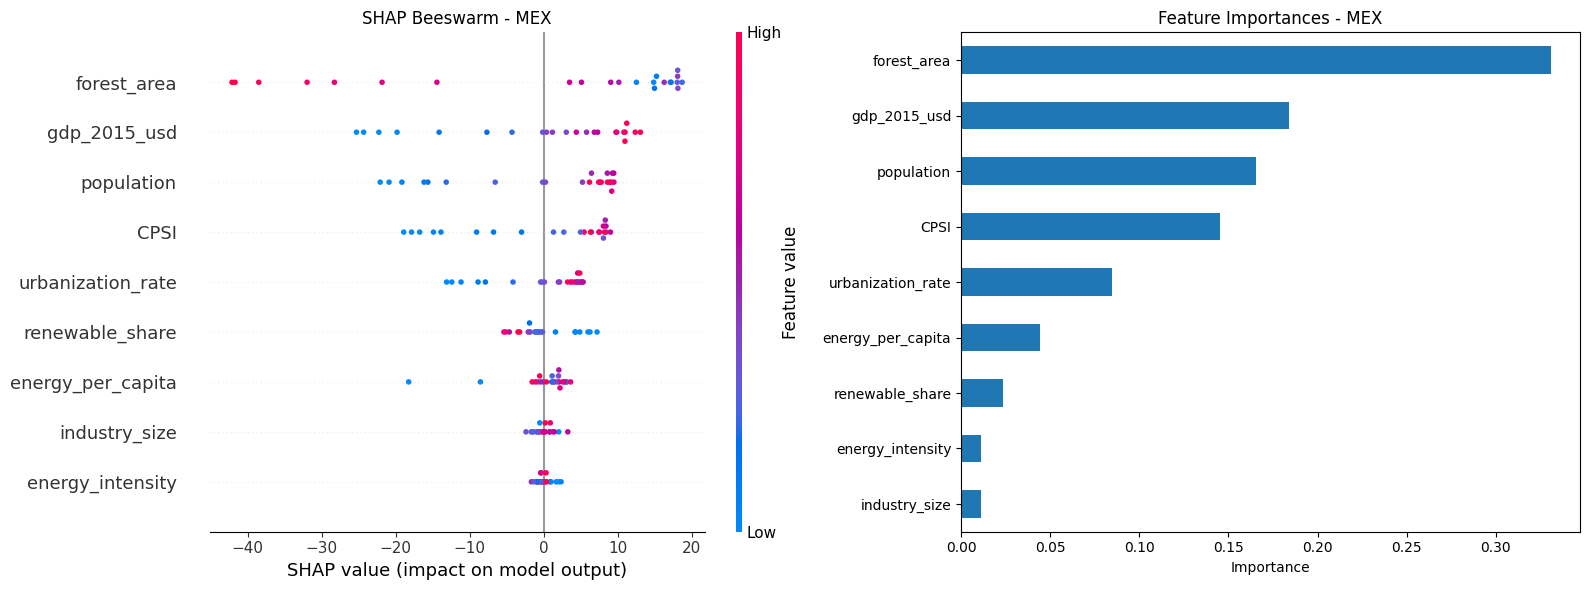

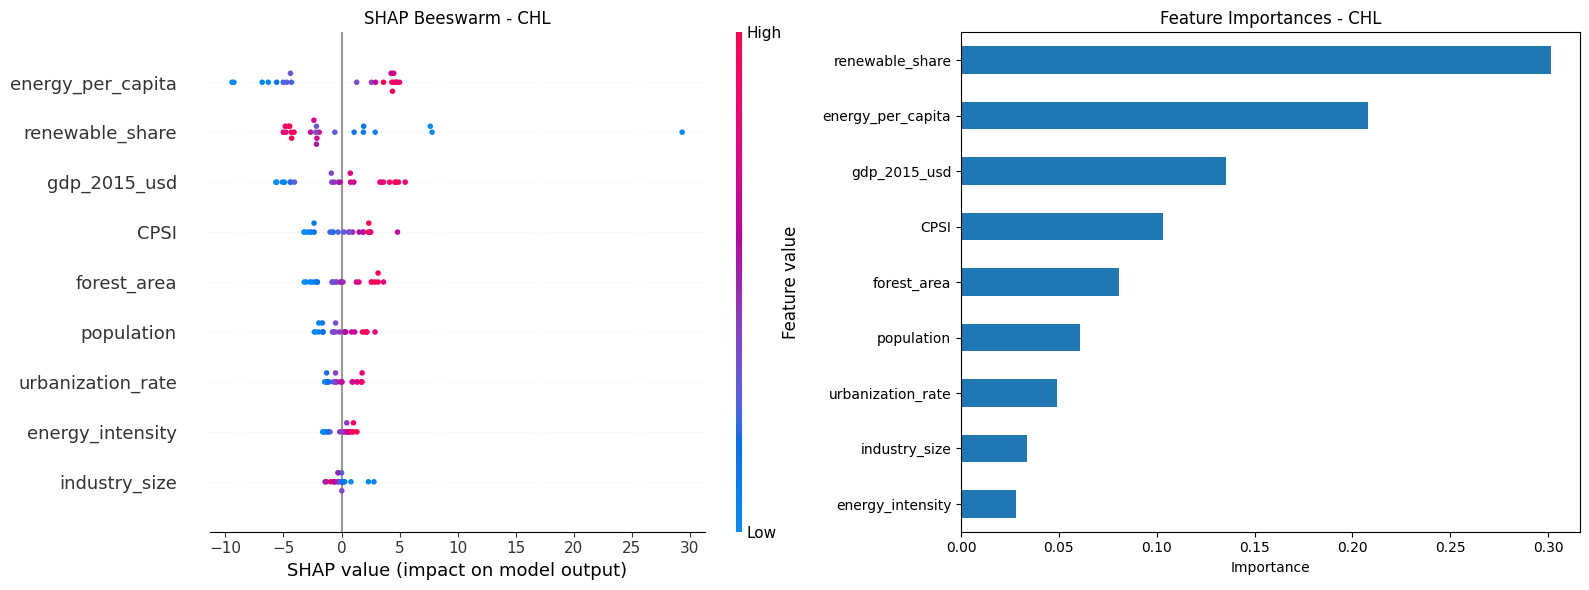

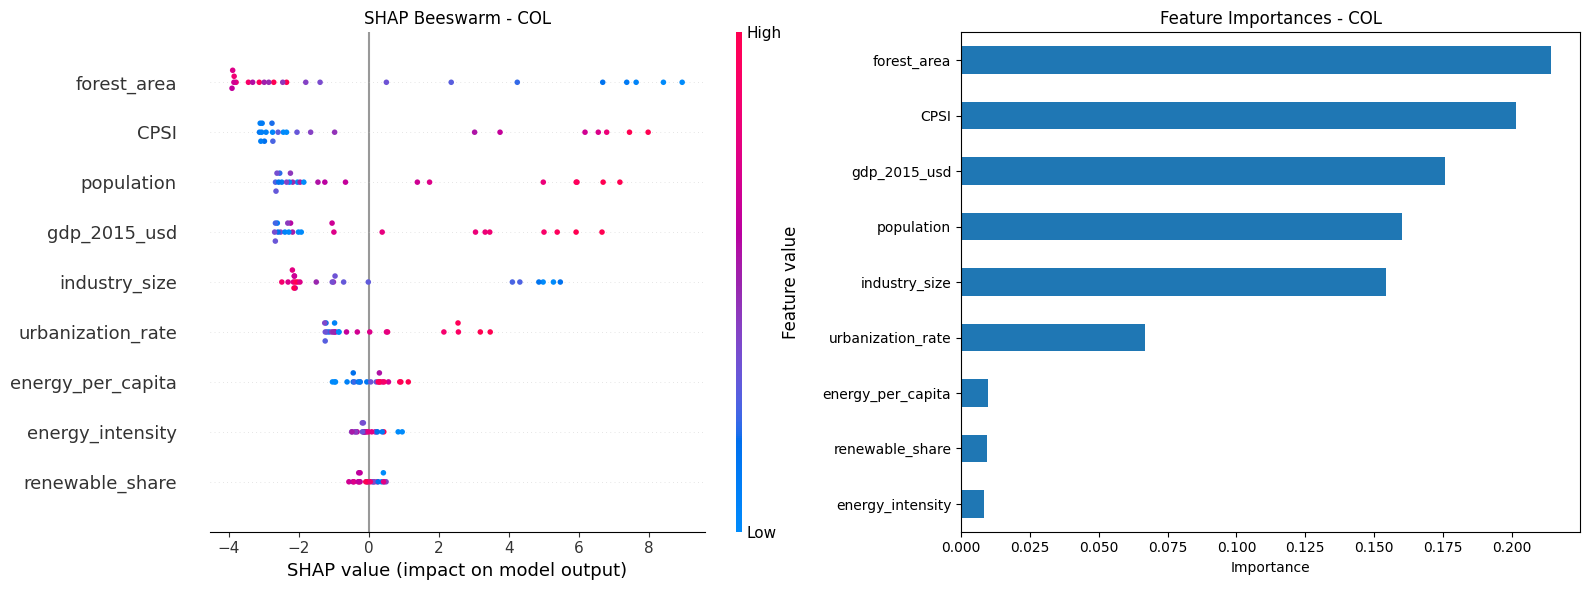

2025-06-10 18:39:16,798 - ERROR - Error for country HRV: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by RandomForestRegressor.
2025-06-10 18:39:16,802 - ERROR - Error for country UGA: Found array with 0 sample(s) (shape=(0, 9)) while a minimum of 1 is required by RandomForestRegressor.


In [39]:
for iso3 in interesting_countries:
    filtered_df = oecd_policy_emissions_df[oecd_policy_emissions_df["iso_alpha_3"] == iso3].copy()
    sutils.analyze_feature_importance_with_shap(filtered_df, FEATURES, target="total_emissions", country=iso3)